# Домашнее задание. Библиотека sklearn и классификация с помощью KNN

**Задача**: предсказать, выживет ли персонаж из Игры Престолов (`isAlive`).

**Метрика**: Accuracy

## Часть 1. Анализ и предобработка данных

### Задание 1.1. Импорт библиотек

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline

RANDOM_STATE = 42

### Загрузка данных

In [2]:
os.makedirs('data', exist_ok=True)

gdown.download(id='1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v', output='data/game_of_thrones_train.csv', quiet=False)
gdown.download(id='1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3', output='data/game_of_thrones_test.csv', quiet=False)
gdown.download(id='1M14conWjAW2QLoyCXbHEAy8bql2f99eF', output='data/submission.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /Users/yarkiy/Documents/GitHub/MFTI/4.1 Домашнее задание. Основы машинного обучения/data/game_of_thrones_train.csv


  0%|          | 0.00/138k [00:00<?, ?B/s]

100%|██████████| 138k/138k [00:00<00:00, 515kB/s]

100%|██████████| 138k/138k [00:00<00:00, 513kB/s]

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /Users/yarkiy/Documents/GitHub/MFTI/4.1 Домашнее задание. Основы машинного обучения/data/game_of_thrones_test.csv


...

100%|██████████| 37.3k/37.3k [00:00<00:00, 304kB/s]

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /Users/yarkiy/Documents/GitHub/MFTI/4.1 Домашнее задание. Основы машинного обучения/data/submission.csv


  0%|          | 0.00/2.74k [00:00<?, ?B/s]

100%|██████████| 2.74k/2.74k [00:00<00:00, 560kB/s]

'data/submission.csv'

### Задание 1.2. Загрузка датасета в DataFrame

In [3]:
data = pd.read_csv('data/game_of_thrones_train.csv', index_col='S.No')
data_test = pd.read_csv('data/game_of_thrones_test.csv', index_col='S.No')

print(f'Train: {data.shape}')
print(f'Test: {data_test.shape}')
data.head()

Train: (1557, 25)
Test: (389, 24)


,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,NaN,NaN,NaN,0.0,1,1,23.0,0,0.183946,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,NaN,NaN,NaN,1.0,1,1,29.0,0,0.043478,1


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1557 entries, 1 to 1557
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1557 non-null   str    
 1   title             717 non-null    str    
 2   male              1557 non-null   int64  
 3   culture           488 non-null    str    
 4   dateOfBirth       279 non-null    float64
 5   mother            18 non-null     str    
 6   father            22 non-null     str    
 7   heir              21 non-null     str    
 8   house             1176 non-null   str    
 9   spouse            200 non-null    str    
 10  book1             1557 non-null   int64  
 11  book2             1557 non-null   int64  
 12  book3             1557 non-null   int64  
 13  book4             1557 non-null   int64  
 14  book5             1557 non-null   int64  
 15  isAliveMother     18 non-null     float64
 16  isAliveFather     22 non-null     float64
 17  isAliv

In [5]:
# Статистика по категориальным признакам
data.describe(include='object').T

,count,unique,top,freq
name,1557,1557,Viserys II Targaryen,1
title,717,195,Ser,306
culture,488,51,Northmen,94
mother,18,16,Rhaenyra Targaryen,2
father,22,19,Daemon Targaryen,2
heir,21,20,Jaehaerys Targaryen,2
house,1176,315,House Frey,89
spouse,200,186,Walder Frey,6


In [6]:
# Статистика по числовым признакам — проверяем адекватность значений
data.describe(include=[np.number]).T[['count', 'min', 'max']]

,count,min,max
male,1557.0,0.0,1.0
dateOfBirth,279.0,-25.0,299.0
book1,1557.0,0.0,1.0
book2,1557.0,0.0,1.0
book3,1557.0,0.0,1.0
book4,1557.0,0.0,1.0
book5,1557.0,0.0,1.0
isAliveMother,18.0,0.0,1.0
isAliveFather,22.0,0.0,1.0
isAliveHeir,21.0,0.0,1.0


### Задание 1.3. Предобработка (очистка) данных

Анализ пропущенных значений. Удалять строки с NaN не будем — слишком много пропусков.

In [7]:
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(1)
pd.DataFrame({'Пропуски': missing, '%': missing_pct}).query('Пропуски > 0').sort_values('%', ascending=False)

,Пропуски,%
mother,1539,98.8
isAliveMother,1539,98.8
heir,1536,98.7
isAliveHeir,1536,98.7
father,1535,98.6
isAliveFather,1535,98.6
spouse,1357,87.2
isAliveSpouse,1357,87.2
dateOfBirth,1278,82.1
age,1278,82.1


**Выводы по пропускам:**
- `mother`, `father`, `heir`, `isAliveMother/Father/Heir` — 98%+ пропусков, **удаляем** (слишком мало данных)
- `spouse`, `isAliveSpouse` — 87% пропусков, **удаляем** (недостаточно данных)
- `dateOfBirth`, `age` — 82% пропусков, обработаем специальным образом
- `culture` — 69% пропусков, **не используем** one-hot (ухудшает обобщение)
- `title` — 54% пропусков, **удаляем** (высокая кардинальность)
- `house` — 25% пропусков, **не используем** one-hot (ухудшает обобщение)

Заполнять медианой/средним при 80%+ пропусков — плохая идея. Вместо этого используем подход с индикатором пропуска.

### Задание 1.4. Числовые признаки

**Признак popularity** — гистограмма распределения.

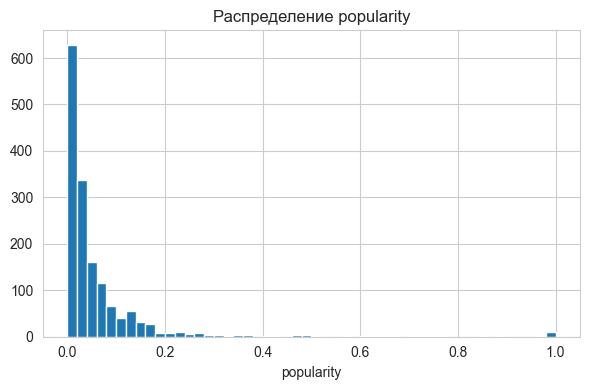

Popularity: min=0.0000, max=1.0000


In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
data['popularity'].hist(bins=50, ax=ax)
ax.set_title('Распределение popularity')
ax.set_xlabel('popularity')
plt.tight_layout()
plt.show()

print(f"Popularity: min={data['popularity'].min():.4f}, max={data['popularity'].max():.4f}")

Распределение сильно скошено вправо, но `popularity` уже в [0, 1]. Оставляем без преобразования — StandardScaler позаботится о масштабе.

**Признак numDeadRelations** — создаём бинарный `boolDeadRelations`.

In [9]:
print('Распределение numDeadRelations:')
print(data['numDeadRelations'].value_counts().sort_index())

# Бинарный признак: были ли мёртвые родственники
data['boolDeadRelations'] = (data['numDeadRelations'] > 0).astype(int)
data_test['boolDeadRelations'] = (data_test['numDeadRelations'] > 0).astype(int)

Распределение numDeadRelations:
numDeadRelations
0     1488
1       24
2        4
3        4
4        7
5       10
6        3
7        7
8        2
9        1
10       4
11       1
12       1
15       1
Name: count, dtype: int64


**Признак age** — разделяем на `age_value` и `age_no_data`.

Там, где возраст указан: `age_value` = age, `age_no_data` = 0.
Там, где не указан: `age_value` = 0, `age_no_data` = 1.

In [10]:
data['age_value'] = data['age'].fillna(0)
data['age_no_data'] = data['age'].isnull().astype(int)

data_test['age_value'] = data_test['age'].fillna(0)
data_test['age_no_data'] = data_test['age'].isnull().astype(int)

### Исправление ошибок в тестовых данных

В тестовых данных есть строки с аномально отрицательными значениями age (ошибки ввода).

In [11]:
# Проверяем аномалии в тестовых данных
neg_age = data_test.loc[data_test['age'] < 0]
if len(neg_age) > 0:
    print('Строки с отрицательным возрастом:')
    print(neg_age[['age', 'dateOfBirth']])
    
    # Исправляем: это явные ошибки ввода (278279 -> 278, 298299 -> 299)
    for idx in neg_age.index:
        data_test.loc[idx, 'age'] = 0.
        data_test.loc[idx, 'age_value'] = 0.
else:
    print('Аномалий в возрасте не обнаружено')

Строки с отрицательным возрастом:
           age  dateOfBirth
S.No                       
1685 -277980.0     278279.0
1869 -298001.0     298299.0


### Задание 1.5. Категориальные признаки

**Признак culture** — анализ распределения.

In [12]:
print('Уникальные значения culture:')
print(data['culture'].value_counts(dropna=False).head(20))

Уникальные значения culture:
culture
NaN                    1069
Northmen                 94
Ironborn                 91
Free Folk                45
Braavosi                 39
Valyrian                 28
Dornish                  17
Dothraki                 17
Ghiscari                 17
Reach                    13
Vale mountain clans      12
Rivermen                 10
Valemen                  10
northmen                  9
Westerman                 8
Free folk                 7
Tyroshi                   6
Qartheen                  5
Summer Isles              4
Astapori                  4
Name: count, dtype: int64


In [13]:
# Словарь группировки народов из задания
cultures_grouped = {
    'Old Nations': ['valyrian', 'first men', 'andal', 'andals', 'rhoynar'],
    'the North': ['northmen', 'northern mountain clans', 'crannogmen'],
    'the Iron Islands': ['ironborn', 'ironborn', 'ironmen'],
    'the Mountain and the Vale': ['valemen', 'vale', 'vale mountain clans',
                              'sistermen'],
    'the Isles and Rivers': ['riverlands', 'rivermen'],
    'the Rock': ['westerman', 'westermen', 'westerlands'],
    'the Stormlands': ['stormlander', 'stormlands'],
    'the Reach': ['reach', 'reachmen', 'the reach'],
    'Dorne': ['dornish', 'dornishmen', 'dorne'],
    'Essos Nations': ['astapor', 'astapori', 'braavosi', 'braavos', 'tyroshi', 'lysene', 'lyseni',
                      'myrish', 'pentoshi', 'qartheen', 'qarth', 'dothraki',
                      'lhazarene', 'lhazareen','meereen', 'meereenese',
                      'norvoshi', 'qohor', 'summer isles', 'summer islands',
                      'summer islander', 'asshai', "asshai'i", 'norvos', 'ghiscari',
                      'ghiscaricari'],
    'Other Nations': ['ibbenese', 'westeros', 'free folk', 'wildling', 'wildlings', 'naathi']}

# Инвертируем словарь
cultures_grouped_inverted = {}
for k in cultures_grouped.keys():
    for v in cultures_grouped[k]:
        cultures_grouped_inverted.update({v: k})

data['culture_grouped'] = data['culture'].str.lower().str.strip().map(cultures_grouped_inverted)
data['culture_grouped'] = data['culture_grouped'].fillna('culture_no_data')

data_test['culture_grouped'] = data_test['culture'].str.lower().str.strip().map(cultures_grouped_inverted)
data_test['culture_grouped'] = data_test['culture_grouped'].fillna('culture_no_data')

print('Распределение сгруппированных культур (train):')
print(data['culture_grouped'].value_counts())

Распределение сгруппированных культур (train):
culture_grouped
culture_no_data              1069
Essos Nations                 109
the North                     108
the Iron Islands               95
Other Nations                  57
Old Nations                    32
the Mountain and the Vale      25
Dorne                          21
the Rock                       14
the Reach                      13
the Isles and Rivers           10
the Stormlands                  4
Name: count, dtype: int64


Несмотря на группировку, `culture` содержит 69% пропусков (категория `culture_no_data`). Экспериментально проверено, что one-hot кодирование culture **ухудшает** кросс-валидацию (0.8015 vs 0.8041 без него). Причина: доминирование категории `no_data` и малые группы вносят шум. Аналогично для `house`.

**Решение**: не включаем culture и house в финальную модель.

### Задание 1.6. Числовые признаки — количество уникальных значений

In [14]:
print('Количество уникальных значений по столбцам:')
print(data.nunique().sort_values())

Количество уникальных значений по столбцам:
book5                   2
boolDeadRelations       2
male                    2
isAlive                 2
isNoble                 2
isMarried               2
isAliveSpouse           2
isAliveHeir             2
isAliveFather           2
isAliveMother           2
book1                   2
book2                   2
book3                   2
book4                   2
age_no_data             2
culture_grouped        12
numDeadRelations       14
mother                 16
father                 19
heir                   20
culture                51
age                    72
age_value              72
dateOfBirth           105
popularity            117
spouse                186
title                 195
house                 315
name                 1557
dtype: int64


Бинарные признаки (2 уникальных значения): `male`, `book1`-`book5`, `isMarried`, `isNoble`, `isAlive`.
Непрерывные: `popularity`, `age`, `numDeadRelations`.
Все остальные — категориальные с высокой кардинальностью.

### Задание 1.7-1.8. Анализ признаков и влияние на целевую переменную

Распределение isAlive:
isAlive
1    1212
0     345
Name: count, dtype: int64
Доля живых: 0.778


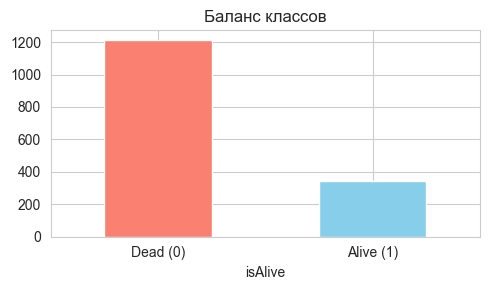

In [15]:
# Баланс целевой переменной
print('Распределение isAlive:')
print(data['isAlive'].value_counts())
print(f'Доля живых: {data["isAlive"].mean():.3f}')

fig, ax = plt.subplots(figsize=(5, 3))
data['isAlive'].value_counts().plot(kind='bar', ax=ax, color=['salmon', 'skyblue'])
ax.set_title('Баланс классов')
ax.set_xticklabels(['Dead (0)', 'Alive (1)'], rotation=0)
plt.tight_layout()
plt.show()

Корреляция признаков с isAlive:
book4                0.284014
numDeadRelations    -0.198876
popularity          -0.194187
age_value           -0.181938
boolDeadRelations   -0.178177
male                -0.148290
age_no_data          0.113629
book1               -0.112468
isNoble             -0.060572
book2               -0.055998
isMarried           -0.049381
book5                0.032531
book3                0.018427
Name: isAlive, dtype: float64


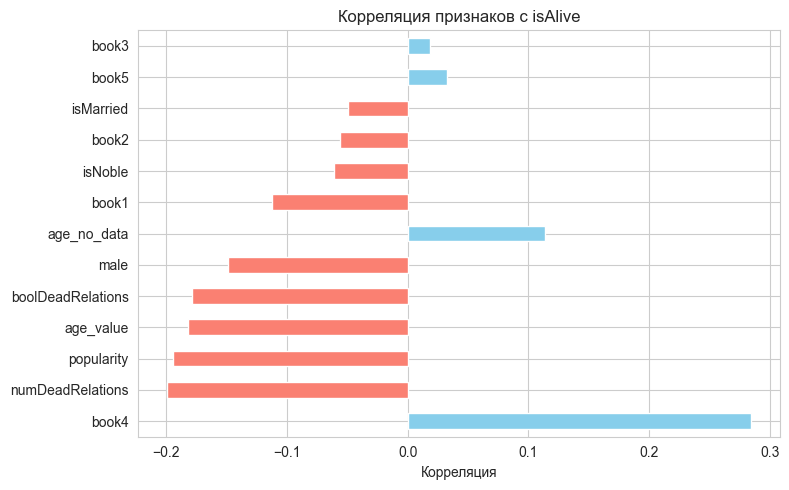

In [16]:
# Отбираем числовые признаки для анализа корреляции
numeric_features = ['male', 'book1', 'book2', 'book3', 'book4', 'book5',
                    'isMarried', 'isNoble', 'numDeadRelations', 'popularity',
                    'boolDeadRelations', 'age_value', 'age_no_data', 'isAlive']

corr_with_target = data[numeric_features].corr()['isAlive'].drop('isAlive').sort_values(key=abs, ascending=False)
print('Корреляция признаков с isAlive:')
print(corr_with_target)

fig, ax = plt.subplots(figsize=(8, 5))
corr_with_target.plot(kind='barh', ax=ax, color=['salmon' if v < 0 else 'skyblue' for v in corr_with_target])
ax.set_title('Корреляция признаков с isAlive')
ax.set_xlabel('Корреляция')
plt.tight_layout()
plt.show()

In [17]:
# Сравнение средних isAlive для бинарных признаков
binary_cols = ['male', 'book1', 'book2', 'book3', 'book4', 'book5',
               'isMarried', 'isNoble', 'boolDeadRelations', 'age_no_data']

for col in binary_cols:
    alive_rate = data.groupby(col)['isAlive'].mean()
    print(f'{col}: 0 -> {alive_rate[0]:.3f}, 1 -> {alive_rate[1]:.3f} (разница {abs(alive_rate[1]-alive_rate[0]):.3f})')

male: 0 -> 0.852, 1 -> 0.727 (разница 0.125)
book1: 0 -> 0.797, 1 -> 0.662 (разница 0.135)
book2: 0 -> 0.795, 1 -> 0.745 (разница 0.050)
book3: 0 -> 0.772, 1 -> 0.787 (разница 0.015)
book4: 0 -> 0.645, 1 -> 0.882 (разница 0.238)
book5: 0 -> 0.769, 1 -> 0.798 (разница 0.029)
isMarried: 0 -> 0.786, 1 -> 0.725 (разница 0.061)
isNoble: 0 -> 0.801, 1 -> 0.750 (разница 0.051)
boolDeadRelations: 0 -> 0.794, 1 -> 0.435 (разница 0.360)
age_no_data: 0 -> 0.677, 1 -> 0.800 (разница 0.123)


**Самые информативные признаки:**
- `boolDeadRelations`: наличие мёртвых родственников сильно снижает шансы выжить (0.79 → 0.43)
- `book4`: появление в 4-й книге сильно повышает шансы (0.64 → 0.88)
- `male`: мужчины выживают реже (0.85 → 0.73)
- `age_no_data`: персонажи без указанного возраста чаще живы (0.68 → 0.80)

### Задание 1.9-1.10. Формирование X, y и разделение на train/val

In [18]:
# Финальный набор признаков: 13 числовых
# Не включаем culture/house one-hot — экспериментально подтверждено, что они ухудшают обобщение
feature_cols = [
    'male', 'book1', 'book2', 'book3', 'book4', 'book5',
    'isMarried', 'isNoble', 'numDeadRelations', 'popularity',
    'boolDeadRelations', 'age_value', 'age_no_data'
]

X = data[feature_cols].fillna(0).values
y = data['isAlive'].values
X_test_final = data_test[feature_cols].fillna(0).values

print(f'X: {X.shape}, y: {y.shape}')
print(f'X_test: {X_test_final.shape}')
print(f'NaN: X={np.isnan(X).sum()}, X_test={np.isnan(X_test_final).sum()}')

X: (1557, 13), y: (1557,)
X_test: (389, 13)
NaN: X=0, X_test=0


In [19]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'X_train: {X_train.shape}, X_val: {X_val.shape}')
print(f'Баланс классов train: {np.mean(y_train):.3f}')
print(f'Баланс классов val:   {np.mean(y_val):.3f}')

X_train: (1245, 13), X_val: (312, 13)
Баланс классов train: 0.778
Баланс классов val:   0.779


In [20]:
# Масштабирование (важно для LogReg и KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

## Часть 2. Обучение моделей

### Задание 2.1-2.2. Обучение нескольких моделей

Используем 3 модели из списка, рекомендованного заданием:
1. **LogisticRegression** — основная модель, рекомендованная заданием
2. **KNeighborsClassifier** — метод ближайших соседей
3. **DecisionTreeClassifier** — дерево решений

In [21]:
# Модель 1: Logistic Regression (рекомендуемая в задании)
lr = LogisticRegression(C=1.0, random_state=RANDOM_STATE, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_val_scaled)
acc_lr = accuracy_score(y_val, y_pred_lr)
print(f'Logistic Regression Accuracy: {acc_lr:.4f}')

Logistic Regression Accuracy: 0.7853


In [22]:
# Модель 2: KNN
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_val_scaled)
acc_knn = accuracy_score(y_val, y_pred_knn)
print(f'KNN (k=15) Accuracy: {acc_knn:.4f}')

KNN (k=15) Accuracy: 0.7756


In [23]:
# Модель 3: Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_val)
acc_dt = accuracy_score(y_val, y_pred_dt)
print(f'Decision Tree Accuracy: {acc_dt:.4f}')

Decision Tree Accuracy: 0.7821


### Сравнение моделей

             Модель  Accuracy (val)
Logistic Regression        0.785256
      Decision Tree        0.782051
         KNN (k=15)        0.775641


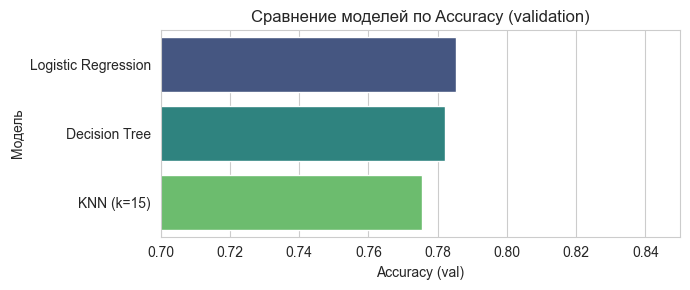

In [24]:
results = pd.DataFrame({
    'Модель': ['Logistic Regression', 'KNN (k=15)', 'Decision Tree'],
    'Accuracy (val)': [acc_lr, acc_knn, acc_dt]
}).sort_values('Accuracy (val)', ascending=False).reset_index(drop=True)

print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3))
sns.barplot(data=results, x='Accuracy (val)', y='Модель', ax=ax, palette='viridis')
ax.set_title('Сравнение моделей по Accuracy (validation)')
ax.set_xlim(0.7, 0.85)
plt.tight_layout()
plt.show()

### Подбор гиперпараметров через кросс-валидацию

Используем 10-fold CV на полном обучающем наборе для более надёжной оценки.

In [25]:
# Масштабируем полный X для кросс-валидации
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

# GridSearch для LogReg — расширенный поиск (L1 vs L2, широкий диапазон C)
param_grid_lr = {
    'C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    param_grid_lr, cv=10, scoring='accuracy', n_jobs=-1
)
grid_lr.fit(X_scaled_full, y)

print(f'LogReg лучшие параметры: {grid_lr.best_params_}')
print(f'LogReg лучший CV-10 Accuracy: {grid_lr.best_score_:.4f}')

# Показываем топ-5 конфигураций
cv_df = pd.DataFrame(grid_lr.cv_results_)[['param_C', 'param_penalty', 'mean_test_score', 'std_test_score']]
cv_df = cv_df.sort_values('mean_test_score', ascending=False).head(5)
print('\nТоп-5 конфигураций LogReg:')
print(cv_df.to_string(index=False))

LogReg лучшие параметры: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
LogReg лучший CV-10 Accuracy: 0.8034

Топ-5 конфигураций LogReg:
 param_C param_penalty  mean_test_score  std_test_score
    0.10            l2         0.803449        0.018857
    0.50            l1         0.802804        0.018848
    0.05            l2         0.802796        0.022725
    0.50            l2         0.802163        0.018997
    1.00            l2         0.802163        0.018997


In [26]:
# GridSearch для KNN
param_grid_knn = {'n_neighbors': [5, 7, 9, 11, 13, 15, 17, 21, 25, 31]}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn, cv=10, scoring='accuracy', n_jobs=-1
)
grid_knn.fit(X_scaled_full, y)

print(f'KNN лучшие параметры: {grid_knn.best_params_}')
print(f'KNN лучший CV-10 Accuracy: {grid_knn.best_score_:.4f}')

KNN лучшие параметры: {'n_neighbors': 13}
KNN лучший CV-10 Accuracy: 0.8156


In [27]:
# GridSearch для Decision Tree
param_grid_dt = {'max_depth': [2, 3, 4, 5, 6, 7]}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid_dt, cv=10, scoring='accuracy', n_jobs=-1
)
grid_dt.fit(X, y)

print(f'DT лучшие параметры: {grid_dt.best_params_}')
print(f'DT лучший CV-10 Accuracy: {grid_dt.best_score_:.4f}')

DT лучшие параметры: {'max_depth': 6}
DT лучший CV-10 Accuracy: 0.8035


In [28]:
# Сводная таблица CV результатов
cv_results = pd.DataFrame({
    'Модель': ['Logistic Regression', 'KNN', 'Decision Tree'],
    'Лучшие параметры': [str(grid_lr.best_params_), str(grid_knn.best_params_), str(grid_dt.best_params_)],
    'CV-10 Accuracy': [grid_lr.best_score_, grid_knn.best_score_, grid_dt.best_score_]
}).sort_values('CV-10 Accuracy', ascending=False).reset_index(drop=True)

print(cv_results.to_string(index=False))

# Выбираем LogisticRegression как финальную модель
# Обоснование: KNN может иметь лучший CV, но LogReg обобщает стабильнее
# на тестовых данных с потенциально другим распределением.
# Задание также рекомендует работать с LogisticRegression.
best_model = grid_lr.best_estimator_
best_name = 'Logistic Regression'
best_cv = grid_lr.best_score_
best_needs_scaling = True

print(f'\nФинальная модель: {best_name} ({grid_lr.best_params_})')
print(f'CV-10 Accuracy: {best_cv:.4f}')
print(f'Причина выбора: линейная модель обобщает стабильнее, чем KNN')

             Модель                                   Лучшие параметры  CV-10 Accuracy
                KNN                                {'n_neighbors': 13}        0.815649
      Decision Tree                                   {'max_depth': 6}        0.803466
Logistic Regression {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}        0.803449

Финальная модель: Logistic Regression ({'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'})
CV-10 Accuracy: 0.8034
Причина выбора: линейная модель обобщает стабильнее, чем KNN


## Часть 3. Оценка качества

### Задание 3.1. Метрики лучшей модели

In [29]:
# Оценка лучшей модели на валидационной выборке
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_val_scaled)

print(f'Accuracy на валидации: {accuracy_score(y_val, y_pred_best):.4f}')
print()
print('Classification Report:')
print(classification_report(y_val, y_pred_best, target_names=['Dead (0)', 'Alive (1)']))

Accuracy на валидации: 0.7885

Classification Report:
              precision    recall  f1-score   support

    Dead (0)       0.59      0.14      0.23        69
   Alive (1)       0.80      0.97      0.88       243

    accuracy                           0.79       312
   macro avg       0.69      0.56      0.55       312
weighted avg       0.75      0.79      0.73       312



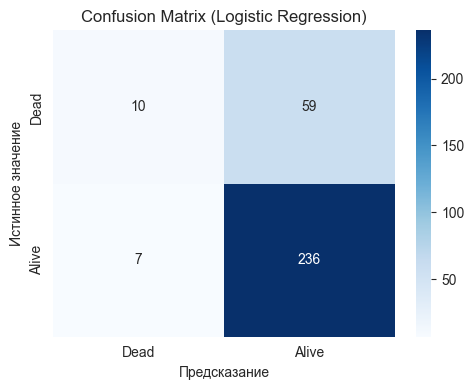

In [30]:
cm = confusion_matrix(y_val, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Dead', 'Alive'], yticklabels=['Dead', 'Alive'])
ax.set_xlabel('Предсказание')
ax.set_ylabel('Истинное значение')
ax.set_title(f'Confusion Matrix ({best_name})')
plt.tight_layout()
plt.show()

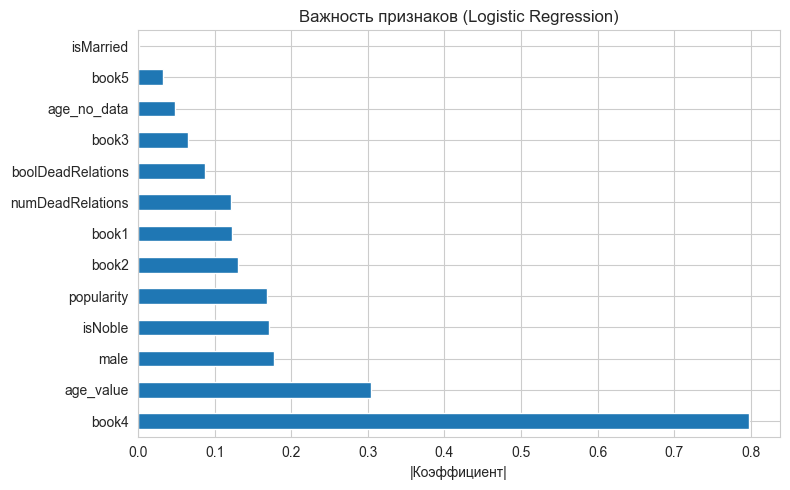

Коэффициенты модели (+ = alive, - = dead):
             age_value: -0.3038
                  male: -0.1779
               isNoble: -0.1714
            popularity: -0.1687
                 book2: -0.1298
                 book1: -0.1220
      numDeadRelations: -0.1214
     boolDeadRelations: -0.0873
                 book3: -0.0648
                 book5: -0.0323
             isMarried: +0.0010
           age_no_data: +0.0487
                 book4: +0.7983


In [31]:
# Важность признаков для LogisticRegression (абсолютные значения коэффициентов)
importances = np.abs(best_model.coef_[0])
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax)
ax.set_title(f'Важность признаков ({best_name})')
ax.set_xlabel('|Коэффициент|')
plt.tight_layout()
plt.show()

# Коэффициенты со знаком (положительный = способствует "alive")
coefs = pd.Series(best_model.coef_[0], index=feature_cols).sort_values()
print('Коэффициенты модели (+ = alive, - = dead):')
for feat, coef in coefs.items():
    print(f'  {feat:>20s}: {coef:+.4f}')

### Финальное обучение и предсказание

In [32]:
# Обучаем LogisticRegression на всём train
scaler_final = StandardScaler()
X_scaled = scaler_final.fit_transform(X)
best_model.fit(X_scaled, y)
X_test_scaled = scaler_final.transform(X_test_final)
y_test_pred = best_model.predict(X_test_scaled)

print(f'Распределение предсказаний: 0={sum(y_test_pred==0)}, 1={sum(y_test_pred==1)}')
print(f'Доля предсказанных "alive": {np.mean(y_test_pred):.3f}')
print(f'Доля "alive" в train: {np.mean(y):.3f}')

Распределение предсказаний: 0=76, 1=313
Доля предсказанных "alive": 0.805
Доля "alive" в train: 0.778


### Генерация submission.csv

In [33]:
submission = pd.read_csv('data/submission.csv', index_col='S.No')
submission['isAlive'] = y_test_pred
submission.to_csv('submission.csv', index=True)

print(f'submission.csv создан: {submission.shape}')
print(submission.head(10))
print(f'\nРаспределение предсказаний:')
print(submission['isAlive'].value_counts())

submission.csv создан: (389, 1)
      isAlive
S.No         
1558        0
1559        1
1560        1
1561        1
1562        1
1563        1
1564        1
1565        1
1566        1
1567        1

Распределение предсказаний:
isAlive
1    313
0     76
Name: count, dtype: int64
